### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Data Understanding

In [2]:
df = pd.read_csv("/Users/bethe/Documents/DS Project/Healthcare Fraud/healthcare_fraud_detection.csv")
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [4]:
df.isnull().sum()/df.shape[0]*100

Provider_ID                              0.0
Claim_ID                                 0.0
Patient_Age                              0.0
Patient_Gender                           0.0
Diagnosis_Code                           0.0
Procedure_Code                           0.0
Claim_Amount                             0.0
Approved_Amount                          0.0
Insurance_Type                           3.5
Claim_Submission_Date                    0.0
Days_Between_Service_and_Claim           0.0
Number_of_Claims_Per_Provider_Monthly    0.0
Provider_Specialty                       3.5
Patient_State                            0.0
Claim_Status                             0.0
Is_Fraud                                 0.0
Length_of_Stay                           0.0
Visit_Type                               0.0
Chronic_Condition_Flag                   0.0
Prior_Visits_12m                         3.5
dtype: float64

In [5]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [6]:
# Hilangkan kolom yang tidak digunakan

df.drop(['Provider_ID', 'Claim_ID', 'Diagnosis_Code', 'Patient_State', 'Procedure_Code', 'Prior_Visits_12m'], axis=1, inplace=True)

In [7]:
df.head()

,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag
0,37,Male,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,Approved,0,0,Outpatient,1
1,21,Female,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,Pending,0,5,Inpatient,1
2,78,Female,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,Pending,0,5,Inpatient,1
3,65,Male,235.15,189.11,Private,2023-10-11,22,70,General Practice,Approved,0,0,Emergency,0
4,36,Male,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,Approved,0,5,Inpatient,0


In [8]:
for col in df.select_dtypes('object').columns:
    print(df[col].value_counts())

Patient_Gender
Female    5001
Male      4999
Name: count, dtype: int64
Insurance_Type
Medicare    2425
Medicaid    2419
Private     2405
Self-Pay    2401
Name: count, dtype: int64
Claim_Submission_Date
2023-09-11    21
2023-08-15    19
2021-12-02    16
2022-07-14    15
2022-01-11    15
              ..
2025-01-22     1
2021-07-10     1
2025-01-23     1
2025-01-17     1
2025-01-26     1
Name: count, Length: 1476, dtype: int64
Provider_Specialty
Internal Medicine    2019
General Practice     1878
Orthopedics          1616
Neurology            1516
Cardiology           1366
Pulmonology          1255
Name: count, dtype: int64
Claim_Status
Approved    7053
Rejected    1748
Pending     1199
Name: count, dtype: int64
Visit_Type
Outpatient    3423
Emergency     3368
Inpatient     3209
Name: count, dtype: int64


In [9]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'], format='%Y-%m-%d')
df['Claim_Submission_mth'] = df['Claim_Submission_Date'].dt.month
df['Claim_Submission_yr'] = df['Claim_Submission_Date'].dt.year

df['Claim_Amount'] = df['Claim_Amount']*17.808
df['Approved_Amount'] = df['Approved_Amount']*17.808

### **Exploratory Data Analysis (EDA)**

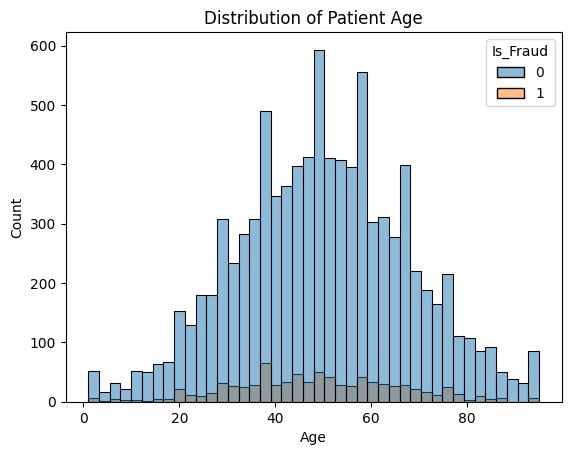

In [10]:
sns.histplot(data=df, x='Patient_Age', hue='Is_Fraud')

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

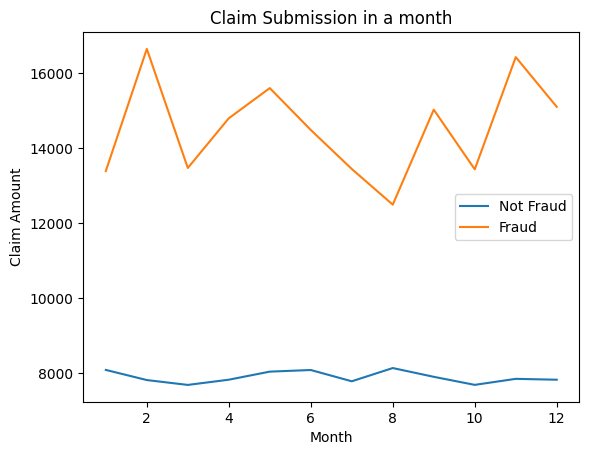

In [11]:
df_fr0 = df[df['Is_Fraud'] == 0].groupby(['Claim_Submission_mth'], as_index=False)['Claim_Amount'].median()
df_fr1 = df[df['Is_Fraud'] == 1].groupby(['Claim_Submission_mth'], as_index=False)['Claim_Amount'].median()

sns.lineplot(df_fr0, x='Claim_Submission_mth', y='Claim_Amount', label='Not Fraud')
sns.lineplot(df_fr1, x='Claim_Submission_mth', y='Claim_Amount', label='Fraud')

plt.title("Claim Submission in a month")
plt.xlabel("Month")
plt.ylabel("Claim Amount")
plt.legend()
plt.show()

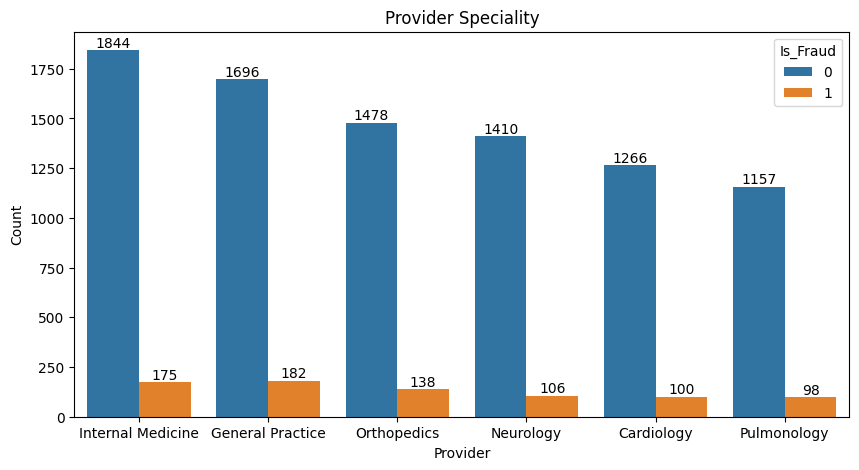

In [12]:
plt.figure(figsize=(10,5))

ax = sns.countplot(df, x=df['Provider_Specialty'], order=df['Provider_Specialty'].value_counts(ascending=False).index, hue='Is_Fraud')

for cnt in ax.containers:
    ax.bar_label(cnt)

plt.title("Provider Speciality")
plt.xlabel("Provider")
plt.ylabel("Count")
plt.show()

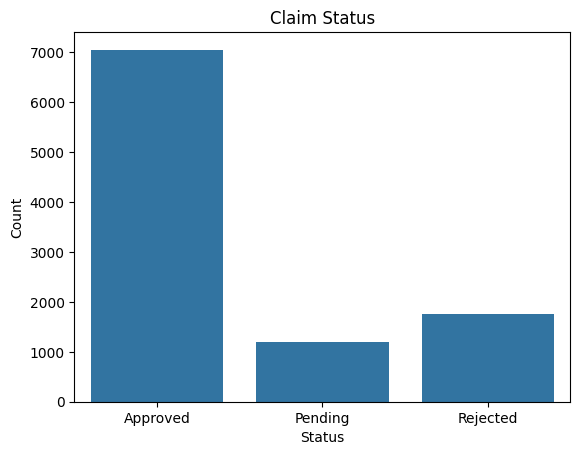

In [13]:
sns.countplot(df, x='Claim_Status')

plt.title("Claim Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Untuk melakukan Machine Learning, akan di ambil data **'Approved'** dan **'Rejected'** sebagai data training

#### Handling Outlier

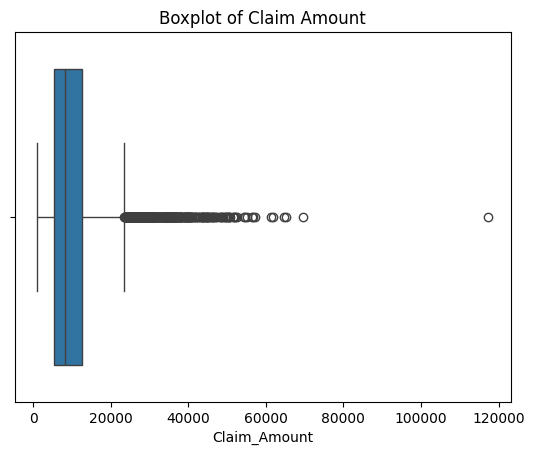

In [ ]:
sns.boxplot(x=df["Claim_Amount"])

plt.title("Boxplot of Claim Amount")
plt.show()

In [ ]:
df[df['Claim_Amount'] > 80000]

,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Claim_Submission_mth,Claim_Submission_yr
0,37,Male,7898.02608,7001.39328,Medicaid,2024-09-01,13,70,Cardiology,Approved,0,0,Outpatient,1,9,2024
1,21,Female,8325.24000,8215.36464,Self-Pay,2022-09-05,5,62,General Practice,Pending,0,5,Inpatient,1,9,2022
2,78,Female,10536.81552,9439.30848,Medicaid,2022-04-11,29,60,Cardiology,Pending,0,5,Inpatient,1,4,2022
4,36,Male,8689.59168,6587.35728,Private,2023-09-05,21,67,Pulmonology,Approved,0,5,Inpatient,0,9,2023
6,50,Male,8166.74880,6630.09648,Medicare,2022-02-20,2,84,Cardiology,Approved,0,0,Outpatient,1,2,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,50,Female,7044.48864,5512.11024,Medicaid,2024-01-22,18,82,Pulmonology,Approved,0,0,Outpatient,1,1,2024
9995,79,Male,10510.10352,3650.64000,Private,2024-09-24,2,115,Internal Medicine,Approved,1,2,Inpatient,1,9,2024
9997,43,Female,8997.31392,7976.91552,Medicare,2024-06-30,6,59,Neurology,Rejected,0,5,Emergency,1,6,2024
9998,39,Female,10048.16400,9031.86144,Medicare,2022-03-15,8,55,Cardiology,Pending,0,5,Emergency,0,3,2022


Tidak di drop karena merupakan informasi penting, yaitu kemungkinan salah satu bukti tanda Fraud.

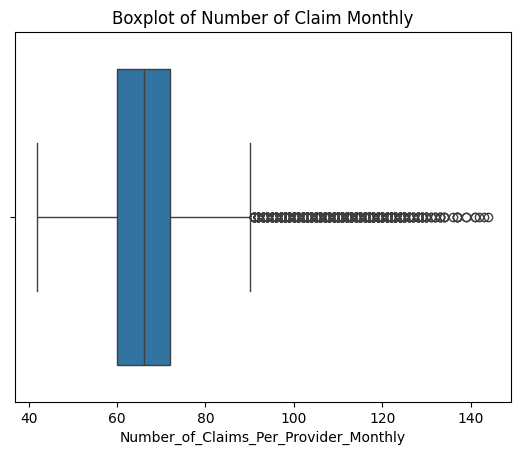

In [ ]:
sns.boxplot(x=df["Number_of_Claims_Per_Provider_Monthly"])

plt.title("Boxplot of Number of Claim Monthly")
plt.show()

In [17]:
df[df['Number_of_Claims_Per_Provider_Monthly'] > 130]

,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Claim_Submission_mth,Claim_Submission_yr
951,34,Male,11789.43024,7983.50448,Self-Pay,2024-09-15,1,133,General Practice,Pending,1,3,Outpatient,1,9,2024
1232,36,Male,18390.67776,5895.87264,Self-Pay,2023-05-11,2,137,Orthopedics,Pending,1,0,Emergency,0,5,2023
1316,41,Female,21240.84816,18797.41248,Self-Pay,2022-02-17,13,133,General Practice,Approved,0,3,Emergency,1,2,2022
1450,63,Female,5581.38336,5504.09664,Private,2023-01-04,4,144,Pulmonology,Approved,0,0,Inpatient,1,1,2023
1529,65,Male,9662.97696,7857.78000,Medicare,2024-09-22,15,132,Internal Medicine,Pending,0,3,Outpatient,0,9,2024
2968,22,Male,15287.09952,12929.32032,Medicare,2022-07-27,6,132,General Practice,Approved,0,0,Inpatient,0,7,2022
4260,64,Female,4958.63760,3834.77472,Self-Pay,2021-02-24,29,132,Pulmonology,Approved,0,3,Emergency,1,2,2021
4438,43,Male,6596.61744,2723.19936,Self-Pay,2022-07-02,4,137,Pulmonology,Approved,1,0,Inpatient,0,7,2022
4714,34,Female,21055.28880,15805.31232,Private,2023-02-14,2,131,Pulmonology,Pending,1,3,Inpatient,1,2,2023
4784,43,Male,12527.39376,10344.84528,Self-Pay,2021-12-02,8,134,Pulmonology,Rejected,0,3,Inpatient,1,12,2021


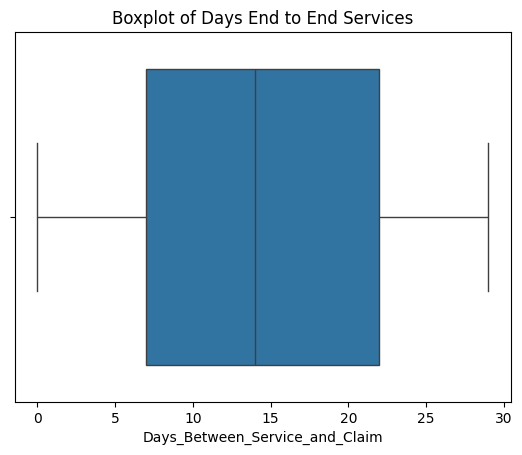

In [18]:
fig, ax = plt.subplots()

sns.boxplot(x=df["Days_Between_Service_and_Claim"])

ax.set_facecolor((0, 0, 0, 0)) #Transparent Background
fig.patch.set_alpha(0.0)

plt.title("Boxplot of Days End to End Services")
plt.show()

In [19]:
q1_num_clm = df["Number_of_Claims_Per_Provider_Monthly"].quantile(0.25)
q3_num_clm = df["Number_of_Claims_Per_Provider_Monthly"].quantile(0.75)

iqr_num_clm = q3_num_clm - q1_num_clm

upper_bound_num_clm = q3_num_clm + (1.5 * iqr_num_clm)

df_clean = df[df['Number_of_Claims_Per_Provider_Monthly'] <= upper_bound_num_clm]
df_clean

,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Claim_Submission_mth,Claim_Submission_yr
0,37,Male,7898.02608,7001.39328,Medicaid,2024-09-01,13,70,Cardiology,Approved,0,0,Outpatient,1,9,2024
1,21,Female,8325.24000,8215.36464,Self-Pay,2022-09-05,5,62,General Practice,Pending,0,5,Inpatient,1,9,2022
2,78,Female,10536.81552,9439.30848,Medicaid,2022-04-11,29,60,Cardiology,Pending,0,5,Inpatient,1,4,2022
3,65,Male,4187.55120,3367.67088,Private,2023-10-11,22,70,General Practice,Approved,0,0,Emergency,0,10,2023
4,36,Male,8689.59168,6587.35728,Private,2023-09-05,21,67,Pulmonology,Approved,0,5,Inpatient,0,9,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,50,Female,7044.48864,5512.11024,Medicaid,2024-01-22,18,82,Pulmonology,Approved,0,0,Outpatient,1,1,2024
9996,66,Male,3912.95184,3417.17712,Self-Pay,2023-01-04,6,73,Orthopedics,Approved,0,5,Inpatient,0,1,2023
9997,43,Female,8997.31392,7976.91552,Medicare,2024-06-30,6,59,Neurology,Rejected,0,5,Emergency,1,6,2024
9998,39,Female,10048.16400,9031.86144,Medicare,2022-03-15,8,55,Cardiology,Pending,0,5,Emergency,0,3,2022


In [20]:
# df_clean[['Insurance_Type', 'Provider_Specialty']] = df_clean[['Insurance_Type', 'Provider_Specialty']].fillna(df_clean[['Insurance_Type', 'Provider_Specialty']].mode())

In [21]:
df_cleans = df_clean.dropna().reset_index(drop=True)
df_cleans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8555 entries, 0 to 8554
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Patient_Age                            8555 non-null   int64         
 1   Patient_Gender                         8555 non-null   object        
 2   Claim_Amount                           8555 non-null   float64       
 3   Approved_Amount                        8555 non-null   float64       
 4   Insurance_Type                         8555 non-null   object        
 5   Claim_Submission_Date                  8555 non-null   datetime64[ns]
 6   Days_Between_Service_and_Claim         8555 non-null   int64         
 7   Number_of_Claims_Per_Provider_Monthly  8555 non-null   int64         
 8   Provider_Specialty                     8555 non-null   object        
 9   Claim_Status                           8555 non-null   object  

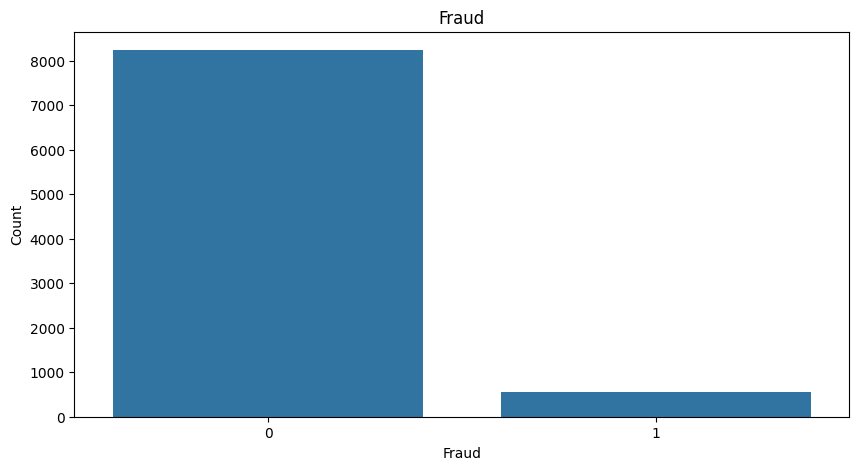

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(df[(df['Claim_Status'] == 'Approved') | (df['Claim_Status'] == 'Rejected')], x='Is_Fraud', ax=ax)

ax.set_facecolor((0, 0, 0, 0)) #Transparent Background
fig.patch.set_alpha(0.0)

plt.title("Fraud")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

In [23]:
df_cleans.drop(['Claim_Submission_Date', 'Approved_Amount'], axis=1, inplace=True)

### Handling Imbalance Data

In [24]:
from imblearn.over_sampling import SMOTENC

TRAIN = df_cleans[(df_cleans['Claim_Status'] == 'Approved') | (df_cleans['Claim_Status'] == 'Rejected')].drop(['Claim_Status'], axis=1)
TEST = df_cleans[df_cleans['Claim_Status'] == 'Pending'].drop(['Claim_Status'], axis=1)

X_train = TRAIN.drop(['Is_Fraud'], axis=1)
X_test = TEST.drop(['Is_Fraud'], axis=1)

y_train = TRAIN['Is_Fraud']
y_test = TEST['Is_Fraud']

categorical_indices = [
    X_train.columns.get_loc(col)
    for col in X_train.select_dtypes('object').columns
]

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=22
)

X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

### Data Preparation & Train Data

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

scaler = StandardScaler()
ohe = OneHotEncoder(drop='first')

numeric_features = X_train.select_dtypes('number').columns
categorical_features = X_train.select_dtypes('object').columns

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=22
)

preprocessor = ColumnTransformer([
    ('num', scaler, numeric_features),
    ('cat', ohe, categorical_features)
])

pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', xgb)
])

pipeline.fit(X_resampled, y_resampled)

y_pred = pipeline.predict(X_test)

              precision    recall  f1-score   support

   Not Fraud       0.94      0.93      0.93       804
       Fraud       0.73      0.74      0.73       201

    accuracy                           0.89      1005
   macro avg       0.83      0.84      0.83      1005
weighted avg       0.89      0.89      0.89      1005

Recall Score:  0.7412935323383084


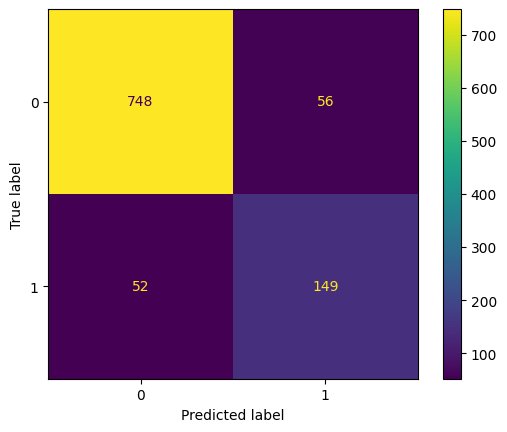

In [26]:
# Evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, recall_score

target_names = ['Not Fraud', 'Fraud']
print(classification_report(y_test, y_pred, target_names=target_names))

print('Recall Score: ', recall_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipeline.classes_)
disp.plot()
plt.show()

In [27]:
# Feature Importance

model = pipeline.named_steps['model']

importance = model.feature_importances_

feature_names = pipeline.named_steps[
    'pre'
].get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(10))

                                     feature  importance
0        num__Days_Between_Service_and_Claim    0.566091
1                num__Chronic_Condition_Flag    0.092947
2                   num__Claim_Submission_yr    0.057182
3                        num__Length_of_Stay    0.051209
4                          num__Claim_Amount    0.044469
5                  num__Claim_Submission_mth    0.022614
6                cat__Insurance_Type_Private    0.018141
7               cat__Insurance_Type_Medicare    0.016724
8  cat__Provider_Specialty_Internal Medicine    0.016316
9               cat__Insurance_Type_Self-Pay    0.014552


### **Deployment**

In [28]:
import joblib

joblib.dump(pipeline, "fraud_pipeline.pkl")
print("✅ Model saved with joblib!")

✅ Model saved with joblib!


In [29]:
import sklearn

print(sklearn.__version__)

1.6.1


In [ ]:
!streamlit run app.py

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

In [3]:
import sklearn
print(sklearn.__version__)

1.6.1


In [4]:
import sklearn
import streamlit as st

st.write("sklearn version:", sklearn.__version__)

2026-06-04 22:01:55.171 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 22:01:56.357 
  command:

    streamlit run C:\Users\bethe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-04 22:01:56.357 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 22:01:56.358 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 22:01:56.358 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 22:01:56.359 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-04 22:01:56.359 Thread 'MainThread': missing ScriptRunContext! This w